# Clasificadores KNN y RNN con el dataset `digits`

En este cuaderno se comparan dos clasificadores basados en vecinos:

- **KNN (`KNeighborsClassifier`)**: usa exactamente `K` vecinos.
- **RNN (`RadiusNeighborsClassifier`)**: usa todos los vecinos que estén dentro de un radio `R`.

El dataset `digits` de `scikit-learn` contiene imágenes de dígitos escritos a mano. Se reserva el 80 % de los datos para entrenamiento y el 20 % para prueba. La selección de `K` y `R` se realiza únicamente con validación cruzada estratificada de 4 particiones sobre el conjunto de entrenamiento, evitando usar el conjunto de prueba durante la selección.

In [8]:
# Si scikit-learn no está instalado en el kernel, descomenta y ejecuta la siguiente línea:
# %pip install scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)

RANDOM_STATE = 42
N_SPLITS = 4
SCORING = {
    "accuracy": "accuracy",
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),
}

digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f"Observaciones totales: {len(X)}")
print(f"Entrenamiento: {len(X_train)} ({len(X_train) / len(X):.0%})")
print(f"Prueba: {len(X_test)} ({len(X_test) / len(X):.0%})")
print(f"Características por imagen: {X.shape[1]}")

Observaciones totales: 1797
Entrenamiento: 1437 (80%)
Prueba: 360 (20%)
Características por imagen: 64


## 1. Selección de `K` para KNN

Se prueban valores impares de `K` entre 1 y 15. La estandarización se incluye dentro de un `Pipeline`, por lo que se ajusta de nuevo en cada partición y no produce fuga de información. El criterio principal de selección será el **F1 macro**; también se reportan accuracy, precision y recall macro.

In [ ]:
k_values = list(range(1, 16, 2))
knn_cv_rows = []

for k in k_values:
    knn_model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(n_neighbors=k)),
    ])
    scores = cross_validate(knn_model, X_train, y_train, cv=cv, scoring=SCORING)
    knn_cv_rows.append({
        "K": k,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision macro": scores["test_precision_macro"].mean(),
        "Recall macro": scores["test_recall_macro"].mean(),
        "F1 macro": scores["test_f1_macro"].mean(),
    })

knn_results = pd.DataFrame(knn_cv_rows)
best_k = int(knn_results.loc[knn_results["F1 macro"].idxmax(), "K"])

ax = knn_results.set_index("K").plot(marker="o", figsize=(10, 5), ylim=(0.85, 1.01))
ax.set_title("KNN: métricas promedio en validación cruzada de 4 folds")
ax.set_xlabel("Número de vecinos (K)")
ax.set_ylabel("Puntuación")
ax.grid(alpha=0.3)
plt.xticks(k_values)
plt.legend(loc="lower right")
plt.show()

display(knn_results.style.format({column: "{:.4f}" for column in knn_results.columns if column != "K"}))
print(f"Mejor K según F1 macro: {best_k}")

,K,Accuracy,Precision macro,Recall macro,F1 macro
0,1,0.9687,0.9697,0.9685,0.9685
1,3,0.9722,0.9730,0.9720,0.9721
2,5,0.9756,0.9762,0.9756,0.9755
3,7,0.9743,0.9750,0.9740,0.9741
4,9,0.9680,0.9690,0.9677,0.9678
5,11,0.9652,0.9661,0.9650,0.9650
6,13,0.9555,0.9568,0.9552,0.9551
7,15,0.9534,0.9550,0.9531,0.9530


Figura guardada en knn_metricas.png
Mejor K según F1 macro: 5


In [ ]:
radius_values = np.arange(1.0, 8.1, 0.5)
rnn_cv_rows = []

for radius in radius_values:
    rnn_model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", RadiusNeighborsClassifier(
            radius=radius,
            outlier_label="most_frequent",
            weights="distance",
        )),
    ])
    scores = cross_validate(rnn_model, X_train, y_train, cv=cv, scoring=SCORING)
    rnn_cv_rows.append({
        "R": radius,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision macro": scores["test_precision_macro"].mean(),
        "Recall macro": scores["test_recall_macro"].mean(),
        "F1 macro": scores["test_f1_macro"].mean(),
    })

rnn_results = pd.DataFrame(rnn_cv_rows)
best_r = float(rnn_results.loc[rnn_results["F1 macro"].idxmax(), "R"])

ax = rnn_results.set_index("R").plot(marker="o", figsize=(10, 5), ylim=(0.80, 1.01))
ax.set_title("RNN: métricas promedio en validación cruzada de 4 folds")
ax.set_xlabel("Radio de vecinos (R)")
ax.set_ylabel("Puntuación")
ax.grid(alpha=0.3)
plt.xticks(radius_values[::2])
plt.legend(loc="lower right")
plt.show()

display(rnn_results.style.format({column: "{:.4f}" for column in rnn_results.columns if column != "R"}))
print(f"Mejor R según F1 macro: {best_r:.1f}")

,R,Accuracy,Precision macro,Recall macro,F1 macro
0,1.000000,0.1016,0.0102,0.1000,0.0184
1,1.500000,0.1016,0.0102,0.1000,0.0184
2,2.000000,0.1044,0.1102,0.1028,0.0240
3,2.500000,0.1406,0.5106,0.1391,0.0905
4,3.000000,0.2596,0.8871,0.2581,0.2711
5,3.500000,0.4419,0.9154,0.4404,0.4936
6,4.000000,0.6479,0.9188,0.6471,0.7023
7,4.500000,0.8017,0.9281,0.8010,0.8325
8,5.000000,0.8824,0.9384,0.8819,0.8957
9,5.500000,0.9172,0.9469,0.9169,0.9240


Figura guardada en rnn_metricas.png
Mejor R según F1 macro: 6.0


## 3. Evaluación final sobre el conjunto de prueba

Después de elegir `K` y `R` usando solo el entrenamiento, cada modelo se ajusta con las 1.437 observaciones de entrenamiento y se evalúa una sola vez sobre las 360 observaciones de prueba. Así se obtiene una estimación final no utilizada durante la selección de hiperparámetros.

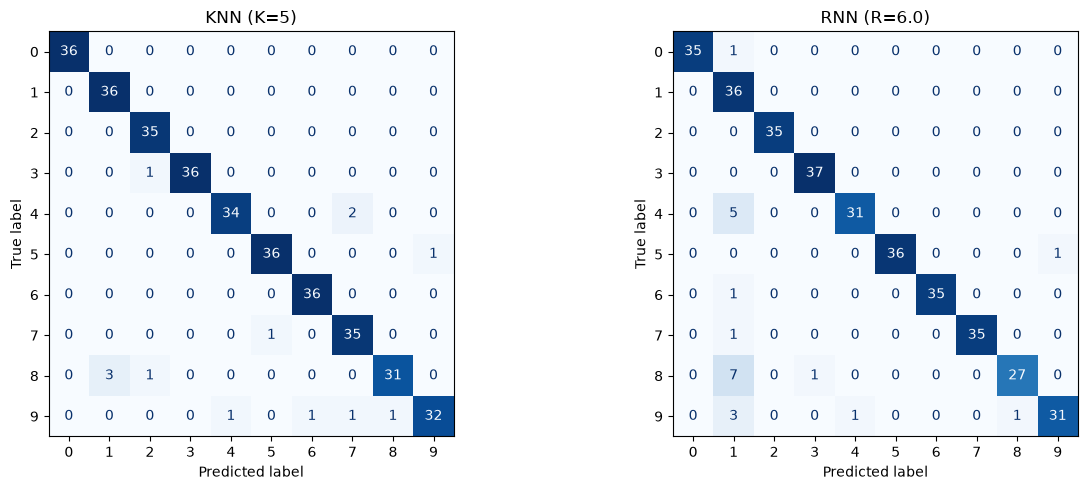

,Modelo,Accuracy,Precision macro,Recall macro,F1 macro
0,KNN (K=5),0.9639,0.9646,0.9637,0.9634
1,RNN (R=6.0),0.9389,0.9542,0.9383,0.9411



KNN (K=5)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       0.95      1.00      0.97        35
           3       1.00      0.97      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      0.97      0.97        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       0.97      0.89      0.93        35
           9       0.97      0.89      0.93        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360


RNN (R=6.0)
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.67      1.00      0.80        36
           2       1.00      1.00      1.00        35


In [14]:
best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=best_k)),
])
best_rnn = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RadiusNeighborsClassifier(
        radius=best_r,
        outlier_label="most_frequent",
        weights="distance",
    )),
])

final_models = {
    f"KNN (K={best_k})": best_knn,
    f"RNN (R={best_r:.1f})": best_rnn,
}
final_rows = []

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for axis, (name, model) in zip(axes, final_models.items()):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    final_rows.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision macro": precision_score(y_test, predictions, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test, predictions, average="macro", zero_division=0),
        "F1 macro": f1_score(y_test, predictions, average="macro", zero_division=0),
    })
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions, ax=axis, cmap="Blues", colorbar=False
    )
    axis.set_title(name)

plt.tight_layout()
plt.show()

final_results = pd.DataFrame(final_rows)
display(final_results.style.format({column: "{:.4f}" for column in final_results.columns if column != "Modelo"}))

for name, model in final_models.items():
    predictions = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, predictions, zero_division=0))